In [1]:
## Load modules ##
import sys;

sys.path.insert(0, '../../');
from methods.config import *
import os
import numpy as np; rnd = np.random.default_rng()
import methods.shared as shared
import pickle
import methods.breseq_util as breseq
from importlib import reload
import copy
reload(breseq)
with open(f'{pickled_dir}/barcode_clone_map.pkl', 'rb') as f:
    barcode_clone_map = pickle.load(f)

with open(f'{pickled_dir}/clone_barcode_map.pkl', 'rb') as f:
    clone_barcode_map = pickle.load(f)

with open(f'{pickled_dir}/mouse_clone_map.pkl', 'rb') as f:
    mouse_clone_map = pickle.load(f)

isolate_gd_dir = f'{data_dir}/isolate_wgs/E1_clones_gd_annotated'
gd_files = os.listdir(isolate_gd_dir)

ordered_barcodes = [(barcode, clones['all']) for barcode, clones in barcode_clone_map.items() if len(barcode) == 20]
ordered_barcodes.sort(key = lambda x:len(x[1]), reverse=True)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/daniel/Documents/GoodLab/btheta_barcoded_evolution/data/clone_seq/E1_clones_gd_annotated'

In [2]:
def filter_mutations_in_sample(all_mutations_dict, sample, evidence, preexisting_variants, exclude_genes={},
                                SV_MIN_FREQ=0.5, SV_MIN_SIZE=10, SV_MIN_COV=5, polymorphism_min=False):
    DEL_evidence = evidence['DEL']
    SNP_evidence = evidence['SNP']
    SUB_evidence = evidence['SUB']
    INS_evidence = evidence['INS']
    JC_evidence = evidence['JC']
    MC_evidence = evidence['MC']

    for mut_type, evidence in zip(['SNP', 'SUB', 'DEL', 'INS'], [SNP_evidence, SUB_evidence, DEL_evidence, INS_evidence]):
        for mut in evidence:
            position, mut_type, mut_dict = mut
            mut_information = [mut_dict[key] for key in ['gene', 'strand', 'gene_description', 'PUL', 'mutation','mutation_description', 'syn']]
            if polymorphism_min:
                freq = mut_dict['frequency']
                if freq < polymorphism_min:
                    continue
            else:
                freq = 1

            key = tuple([position, mut_type] + mut_information)
            if breseq.check_preexisting(key, preexisting_variants, exclude_genes=exclude_genes):
                continue
            if key not in all_mutations_dict:
                all_mutations_dict[key] = {}
            all_mutations_dict[key][sample] = freq

    for mut in JC_evidence:
        (start, end), genes, orientations, freq, JC_coverage = mut
        if freq < SV_MIN_FREQ or end-start < SV_MIN_SIZE or JC_coverage < SV_MIN_COV:
            continue

        key = ((start, end), 'JC', genes, orientations)
        if breseq.check_preexisting(key, preexisting_variants, exclude_genes=exclude_genes):
            continue

        if key not in all_mutations_dict:
            all_mutations_dict[key] = {}
        all_mutations_dict[key][sample] = (freq, JC_coverage)

    for mut in MC_evidence:
        (start, end), genes = mut
        if (end - start) < SV_MIN_SIZE:
            continue

        key = ( (start, end), 'MC', genes )
        if breseq.check_preexisting(key, preexisting_variants, exclude_genes=exclude_genes):
            continue

        if key not in all_mutations_dict:
            all_mutations_dict[key] = {}
        all_mutations_dict[key][sample] = 0

In [3]:
# n_clones = len(clone_evidence_map.keys())
# for mut, clones in list(all_mutations.items()):
#     count = len(clones)
#     if count > 0.75*n_clones and count < n_clones:
#         # print(mut, n_clones-count)
#         barcodes_not_represented = []
#         n_count = 0
#         for barcode, barcode_clones in ordered_barcodes:
#             if np.sum([clone in barcode_clones for clone in clones]) < 1/2*len(barcode_clones):
#                 barcodes_not_represented.append([barcode, len(barcode_clones)])
#                 n_count += len(barcode_clones) - np.sum([clone in barcode_clones for clone in clones])
    
#         print(mut, len(barcodes_not_represented), n_count/(n_clones-count), barcodes_not_represented)

In [2]:
## Are there any systematic differences between plate1 and plate2 barcode mutations?

for mut, mut_freqs in day0_mutations.items():
    if 'E1_plate1' in mut_freqs and 'E1_plate2' not in mut_freqs:
        if np.any([E2_set in mut_freqs for E2_set in ['E2_S1', 'E2_S2']]) and ~np.any([E2_set in mut_freqs for E2_set in ['E2_S3', 'E2_S4']]):
            print(mut[0], mut[2], mut[1], mut_freqs['E1_plate1'])
    if 'E1_plate2' in mut_freqs and 'E1_plate1' not in mut_freqs:
        if np.any([E2_set in mut_freqs for E2_set in ['E2_S3', 'E2_S4']]) and ~np.any([E2_set in mut_freqs for E2_set in ['E2_S1', 'E2_S2']]):
            print(mut[0], mut[2], mut[1], mut_freqs)
    if 'E2_S5' in mut_freqs and ~np.any([E2_set in mut_freqs for E2_set in ['E2_S3', 'E2_S4', 'E1_plate2', 'invitro_S4', 'invitro_S5', 'invitro_S6']]):
        print(mut[0], mut[2], mut[1], mut_freqs)

    

NameError: name 'day0_mutations' is not defined

Look through all day 0 libraries, find mutations at substantial frequencies in at least 2 libraries --> potential pre-existing, artifact, or hypermutable
Also look through all ISOLATES, find mutations found in a majority --> pre-existing, artifact, or hypermutable

In [4]:
EXCLUSION_LIST = ['BT1040/BT1041', 'BT1042', 'BT3239/BT3240', 'BT4054/BT4055', 'BT2672/BT2673'] #loci that appear hypermutable and/or sequencing artifacts
# EXCLUSION_LIST = ['BT1042', 'BT2672/BT2673'] #loci that appear hypermutable and/or sequencing artifacts
MIN_FREQ_DAY0 = 0.1
SV_MIN_FREQ = 0.1
SV_MIN_SIZE = 10
SV_MIN_COV = 5
MIN_PREVALENCE_IN_CLONES = 0.9

### day 0 ###
# Get a list of (point-like) mutations that are present in at least 2 replicates at frequency > 0.1 
day0_evidence_map = {}
day0_gd_dir = f'{data_dir}/reference_genome/day0_gd_annotated'
day0_gd_files = os.listdir(day0_gd_dir)
print(f'Searching through {len(day0_gd_files)} day 0 libraries')

for file in day0_gd_files:
    if 'gd' not in file: continue
    replicate = file.replace('_day0_annotated.gd', '')
    coverage, rep_evidence = breseq.get_variants_from_annotated_gd_file(f'{day0_gd_dir}/{file}', freq=True)
    day0_evidence_map[replicate] = {'coverage':coverage, 'evidence':rep_evidence}

day0_mutations = {}
for rep, barcode_evidence_dict in day0_evidence_map.items():
    evidence = day0_evidence_map[rep]['evidence']
    filter_mutations_in_sample(day0_mutations, rep, evidence, [], exclude_genes={}, polymorphism_min=MIN_FREQ_DAY0)
    
all_day0_mutations = copy.copy(day0_mutations)

for mut, replicates in list(day0_mutations.items()): # only keep mutations that are present in at least 2 replicates
    # if mut[2] == 'BT1040/BT1041':
    #     print(mut, replicates)
    if mut in EXCLUSION_LIST:
        print('day0', mut, replicates)
        continue
    if len(replicates) < 2:
        del day0_mutations[mut]

### all isolates ### 
n_clones = 0
clone_evidence_map = {}
for file in gd_files:
    (mouse, day, clone) = breseq.parse_isolate_gd_filename(file)
    if (mouse, day, clone) not in clone_barcode_map.keys(): #ignores low-coverage or nonclonal colonies
        continue
    barcode = clone_barcode_map[(mouse, day, clone)]
    coverage, isolate_evidence = breseq.get_variants_from_annotated_gd_file(f'{isolate_gd_dir}/{file}')

    clone_evidence_map[(mouse, day, clone)] = {'barcode':barcode, 'coverage':coverage, 'evidence':isolate_evidence}
    n_clones += 1

all_mutations = {}
n_clones = len(clone_evidence_map.keys())
print('Searching through %d clones' % n_clones)
for clone, barcode_evidence_dict in clone_evidence_map.items():
    evidence = barcode_evidence_dict['evidence']
    filter_mutations_in_sample(all_mutations, clone, evidence, [], exclude_genes={},
                                SV_MIN_FREQ=SV_MIN_FREQ, SV_MIN_SIZE=SV_MIN_SIZE, SV_MIN_COV=SV_MIN_COV, polymorphism_min=False)
    

mut_counts = [count for mut, count in all_mutations.items()]
preexisting_mutations = copy.copy(all_mutations)
exclusion_count = 0

for mut, clones in list(preexisting_mutations.items()):
    count = len(clones)
    if mut[2] in EXCLUSION_LIST and count < MIN_PREVALENCE_IN_CLONES * n_clones: #hypermutable?
        exclusion_count += 1
        n_barcodes = len(set([clone_barcode_map[clone] for clone in clones]))
        # print('Excluding variant at hypermutable locus', mut, 'Num clones:', len(clones), 'Num barcodes:', n_barcodes)
        continue
    if count < MIN_PREVALENCE_IN_CLONES * n_clones:
        del preexisting_mutations[mut]
        continue

exclude_muts = [mut for mut, count in preexisting_mutations.items()]
print(f'Exclude {len(preexisting_mutations)-exclusion_count} mutations in >90% ({MIN_PREVALENCE_IN_CLONES*n_clones}) clones')
count = 0 
for mut in list(day0_mutations.keys()):
    if mut not in preexisting_mutations.keys():
        count += 1
        exclude_muts.append(mut)
print(f'Exclude {exclusion_count} addtional mutations at {len(EXCLUSION_LIST)} hypermutable loci')
print(f'Exclude {count} additional mutations found in at least 2 day 0 libraries that are not present in >90% of clones')

with open(f'{pickled_dir}/preexisting_variants.pkl', 'wb') as f:
    pickle.dump(exclude_muts, f)


Searching through 13 day 0 libraries
Searching through 478 clones
Exclude 129 mutations in >90% (430.2) clones
Exclude 63 addtional mutations at 5 hypermutable loci
Exclude 147 additional mutations found in at least 2 day 0 libraries that are not present in >90% of clones


Collect all point-like mutations (SNPs, small INDELs, etc.) in each clone,
screen out those not fixed in certain

In [5]:
MIN_FREQ_DAY0 = 0.1
SV_MIN_FREQ = 0.1
SV_MIN_SIZE = 10
SV_MIN_COV = 5
MIN_PREVALENCE_IN_CLONES = 0.9

## pass back through clones, filtering out 
n_clones = 0
clone_evidence_map = {}
all_mutations_in_isolates = {}
for file in gd_files:
    (mouse, day, clone) = breseq.parse_isolate_gd_filename(file)
    if (mouse, day, clone) not in clone_barcode_map.keys(): #ignores low-coverage or nonclonal colonies
        continue
    barcode = clone_barcode_map[(mouse, day, clone)]
    coverage, isolate_evidence = breseq.get_variants_from_annotated_gd_file(f'{isolate_gd_dir}/{file}')

    clone_evidence_map[(mouse, day, clone)] = {'barcode':barcode, 'coverage':coverage, 'evidence':isolate_evidence}
    n_clones += 1

    ## filter
    filter_mutations_in_sample(all_mutations_in_isolates, (mouse,day,clone),
                                isolate_evidence, exclude_muts, SV_MIN_FREQ=SV_MIN_FREQ, SV_MIN_SIZE=SV_MIN_SIZE, SV_MIN_COV=SV_MIN_COV)

n_simple_mutations = len([mut for mut in all_mutations_in_isolates.keys() if mut[1] in ['SNP', 'SUB', 'DEL', 'INS']])
print("Num. filtered simple mutations:", n_simple_mutations)
for mut in list(all_mutations_in_isolates.keys()):
    if mut[1] not in ['SNP', 'SUB', 'DEL', 'INS']:
        continue
    n_clones_represented = len(all_mutations_in_isolates[mut].keys())
    n_barcodes_represented = len(set(clone_barcode_map[clone] for clone in all_mutations_in_isolates[mut].keys()))
    if n_barcodes_represented > 2:
        print(mut, n_barcodes_represented, n_clones_represented)

barcode_simple_variant_map = {}
for barcode, clones in barcode_clone_map.items():
    all_clones = clones['all']
    muts = []
    for mut, mut_clones in all_mutations_in_isolates.items():
        if mut[1] not in ['SNP', 'SUB', 'DEL', 'INS']:
            continue
        n_clones = np.sum([clone in mut_clones.keys() for clone in all_clones])
        if n_clones > 0.5 * len(all_clones):
            muts.append(mut)
    barcode_simple_variant_map[barcode] = muts

n_barcodes_no_simple_variants = len([barcode for barcode, muts in barcode_simple_variant_map.items() if len(muts) == 0])
print(n_barcodes_no_simple_variants, 'barcodes have no simple variants')
    # if len(clones['all']) > 1:


Num. filtered simple mutations: 68
(1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False') 6 162
128 barcodes have no simple variants


In [6]:
count = 0

JC_list = sorted([(mut, clones) for mut, clones in all_mutations_in_isolates.items() if mut[1] == 'JC'], key=lambda x:x[0][0])
count = len(JC_list)

merged_JCs = {}

d_counts = {'IR-inversion':0, 'insertion':0, 'SV':0}

for i, (mut, mut_clones) in enumerate(JC_list[:-1]):
    mut_start, mut_stop = mut[0]
    mut_orientations = np.array(mut[-1])

    for (next_mut, next_clones) in JC_list[i+1:]:
        next_start, next_stop = next_mut[0]
        next_orientations = np.array(next_mut[-1])

        intersection = tuple(set(mut_clones.keys()).intersection(next_clones.keys()))
        intersection = [(clone, mut_clones[clone], next_clones[clone]) for clone in list(intersection)]
        union = tuple(set(mut_clones.keys()).union(next_clones.keys()))
        if len(intersection) == 0: #only consider merging JC if they share at least one clone
            continue

        # inversion1_bool, ir1_1, ir2_1 = ( breseq.find_spanning_inverted_repeats(mut[0], 3) )
        # inversion2_bool, ir1_2, ir2_2 = ( breseq.find_spanning_inverted_repeats(next_mut[0], 3) )
        # inversion = False
        # if inversion1_bool and inversion2_bool:
        #     inversion = np.all(np.array(ir1_1[0]) == np.array(ir1_2[0])) & np.all(np.array(ir2_1[0]) == np.array(ir2_2[0]))
        inversion = breseq.find_spanning_inverted_repeats(mut[0], next_mut[0], 3) 
        if len(intersection) < 0.5 * np.min([len(mut_clones), len(next_clones)]) or ~(np.abs( mut_start - next_start ) < 50 or np.abs( mut_stop - next_stop ) < 50):
            continue

        flag = 'SV'
        # if np.abs(mut_start - 1854701) < 10:
        #     print(mut, inversion, breseq.find_spanning_inverted_repeats(mut[0], 3), breseq.find_spanning_inverted_repeats(next_mut[0], 3))
        if inversion and (np.abs( mut_start - next_start ) < 50 and np.abs( mut_stop - next_stop ) < 50) \
                and (mut_orientations * next_orientations).sum() == -2:
            flag = 'IR-inversion'
            print('inversion:', mut, next_mut)
        elif (np.abs( mut_start - mut_stop ) > 10000 or np.abs( next_start - next_stop ) > 10000):
            flag = 'insertion'

        d_counts[flag] += 1
        merged_JCs[ tuple([tuple(sorted([mut, next_mut], key=lambda x:x[0]))]) ] = [intersection, flag]

print(d_counts)
merged_JCs_lst = [(key, [clone[0] for clone in val[0]], val[1]) for key, val in merged_JCs.items()]
merged_JCs_lst.sort(key=lambda x:x[0][0])
for pair, data in merged_JCs.items():
    if data[1] == 'IR-inversion':
        print(pair, data[-1])

flattened = [mut_pair[0][0] for mut_pair in merged_JCs] + [mut_pair[0][1] for mut_pair in merged_JCs]
count = len(merged_JCs)
print('Paired JCs:', count)

unpaired_count = 0
for mut, clones in JC_list:
    if mut not in flattened:
        unpaired_count += 1
        merged_JCs_lst.append([(mut,), list(clones.keys()), 'unpaired_JC'])
print('Unpaired JCs:', unpaired_count)
print('Total JCs:', count + unpaired_count)


inversion: ((33697, 33909), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (1, 1)) ((33719, 33885), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (-1, -1))
inversion: ((463097, 463386), 'JC', ('BT0375-BT0376', 'BT0375-BT0376'), (1, 1)) ((463119, 463362), 'JC', ('BT0375-BT0376', 'BT0375-BT0376'), (-1, -1))
inversion: ((735864, 736152), 'JC', ('BT0595-BT0596', 'BT0595-BT0596'), (1, 1)) ((735883, 736131), 'JC', ('BT0595-BT0596', 'BT0595-BT0596'), (-1, -1))
inversion: ((1068507, 1068788), 'JC', ('BT0867-BT0868', 'BT0867-BT0868'), (1, 1)) ((1068528, 1068765), 'JC', ('BT0867-BT0868', 'BT0867-BT0868'), (-1, -1))
inversion: ((2048013, 2048292), 'JC', ('BT1656-BT1657', 'BT1656-BT1657'), (-1, -1)) ((2048014, 2048293), 'JC', ('BT1656-BT1657', 'BT1656-BT1657'), (1, 1))
inversion: ((2419174, 2419474), 'JC', ('BT1927-BT1928', 'BT1927-BT1928'), (1, 1)) ((2419195, 2419451), 'JC', ('BT1927-BT1928', 'BT1927-BT1928'), (-1, -1))
inversion: ((2548175, 2548737), 'JC', ('BT2031', 'BT2031-BT2032'), (1, 1)) ((2548191, 

In [7]:
count = 0
pvals = []

SV_pvals = {}
for (JC, locus_clones, mut_type) in merged_JCs_lst:
    locus_barcodes = set([clone_barcode_map[clone] for clone in locus_clones])
    SV = (*JC, mut_type)

    # cov_pos, cov_neg = [], []
    # for clone, evidence in clone_evidence_map.items():
    #     if clone in locus_clones:
    #         cov_pos.append(evidence['coverage'])
    #     else:
    #         cov_neg.append(evidence['coverage'])

    barcode_locus_list = []
    coverage_detection_tuples = []
    for b, (barcode, barcode_clones) in enumerate(ordered_barcodes):
        n_clones = len(barcode_clones)
        day_lst = [9, 17, 36, 51]

        for day in day_lst:
            if day not in barcode_clone_map[barcode]:
                continue
            day_clones = barcode_clone_map[barcode][day]

            locus_states = [0, 0]
            for clone in day_clones:
                flag = 0
                if clone in locus_clones:
                    flag = 1
                locus_states[flag] += 1
            barcode_locus_list.append(locus_states)
    barcode_locus_arr = np.array(barcode_locus_list)

    present_bool = barcode_locus_arr[:, 1] > 0

    
    if present_bool.sum() <= 1:
        SV_pvals[SV] = (locus_clones, locus_barcodes, np.nan, False) #only single mutation
        continue

    n_clones_per_barcode = barcode_locus_arr.sum(axis=1)
    n_clones_with_JC = barcode_locus_arr[:, 1].sum()
    expected_vec =  n_clones_per_barcode * n_clones_with_JC /  n_clones_per_barcode.sum()

    prob_dist = scipy.stats.multivariate_hypergeom(n_clones_per_barcode, n_clones_with_JC)
    observed_statistic = prob_dist.logpmf(barcode_locus_arr[:, 1])

    pval = 0
    n_samples = 0
    sim_statistics = []
    while n_samples < 10**6 and pval < 0.05:
        sample = prob_dist.rvs(10**5)
        n_samples += 10**5
        broadcast_expected_vec = np.broadcast_to(expected_vec, (sample.shape[0], expected_vec.shape[0]))
        sim_statistics.append(list(prob_dist.logpmf(sample)))
        pval = (np.array(sim_statistics) <= observed_statistic).sum() / n_samples

    pval = np.max([1/10**6, pval])
    SV_pvals[SV] = (locus_clones, locus_barcodes, pval, True)
    print(SV, pval, n_samples)

valid_tested = sorted([(SV, clones, barcodes, pval) for SV, (clones, barcodes, pval, _) in SV_pvals.items() if ~np.isnan(pval)], key=lambda x:x[1])
print(len(valid_tested))
for e, (SV, clones, barcodes, pval) in enumerate(valid_tested):
    SV_pvals[SV] = (clones, barcodes, pval*len(valid_tested)/(e+1), True)

with open(f'{pickled_dir}/SV_pvals.pkl', 'wb') as f:
    pickle.dump(SV_pvals, f)


((((33697, 33909), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (1, 1)), ((33719, 33885), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (-1, -1))), 'IR-inversion') 0.94309 100000
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1))), 'insertion') 1e-06 1000000
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((592458, 4001888), 'JC', ('BT0481', 'BT3134'), (1, 1))), 'insertion') 1e-06 1000000
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((643221, 4001895), 'JC', ('BT0520-BT0521', 'BT3134'), (1, 1))), 'insertion') 1e-06 1000000
((((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1)), ((643224, 4017686), 'JC', ('BT0520-BT0521', 'BT3153-BT3154'), (-1, -1))), 'insertion') 1e-06 1000000
((((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1)), ((643227, 4017683), 'JC', ('BT0520-BT0521', 'BT3153-BT3154'), (-1, -1))), 'insertion') 1e-06 1000000
((((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT

In [7]:
with open(f'{pickled_dir}/SV_pvals.pkl', 'rb') as f:
    SV_pvals = pickle.load(f)


In [8]:
## check for MCs aligning with JCs in same clone --> no clear examples of deletion ...
MC_list = sorted([(mut, clones) for mut, clones in all_mutations_in_isolates.items() if mut[1] == 'MC'], key=lambda x:x[0][0])
x = np.arange(0, shared.GENOME_LENGTH, 10)
z = np.full(len(x), 1)

MC_starts = np.array([MC[0][0][0] for MC in MC_list])
MC_stops = np.array([MC[0][0][1] for MC in MC_list])
MC_clones = [MC[1] for MC in MC_list]

for SV, (SV_clones, SV_barcodes, pval, _) in SV_pvals.items():
    mut_type = SV[-1]
    if mut_type == 'unpaired_JC':
        loc, mut, annotation, idx = SV[0]
        start, stop = loc
        nearby_MC = (np.abs(MC_starts - start)<20) & (np.abs(MC_stops - stop)<20) 
        nearby_idx = np.arange(len(nearby_MC))[nearby_MC]
        if np.any( nearby_MC ):
            for idx in nearby_idx:
                print('N clones with JC evidence:', len(SV_clones), 'intersection with MC evidence:', set(SV_clones).intersection(list(MC_clones[idx].keys())))
    else:
        for (loc, mut, annotation, idx) in SV[0]:
            start, stop = loc
            nearby_MC = (np.abs(MC_starts - start)<20) & (np.abs(MC_stops - stop)<20) 
            nearby_idx = np.arange(len(nearby_MC))[nearby_MC]
            if np.any( nearby_MC ):
                for idx in nearby_idx:
                    print('N clones with JC evidence:', len(SV_clones), 'intersection with MC evidence:', set(SV_clones).intersection(list(MC_clones[idx].keys())))              


N clones with JC evidence: 182 intersection with MC evidence: {(11, 17, 36)}
N clones with JC evidence: 182 intersection with MC evidence: {(11, 17, 36)}


In [9]:
## get frequency of JC in each clone
SV_processed = {}
for SV, (SV_clones, SV_barcodes, pval, tested_bool) in SV_pvals.items():
    mut_type = SV[-1]
    if mut_type != 'unpaired_JC':
        JC1 = SV[0][0]
        JC2 = SV[0][1]

        JC1_frequencies = all_mutations_in_isolates[JC1]
        JC2_frequencies = all_mutations_in_isolates[JC2]

        freqs = []
        for clone in SV_clones:
            JC1_freq, JC1_cov = JC1_frequencies[clone]
            JC2_freq, JC2_cov = JC2_frequencies[clone]
            freqs.append( (JC1_cov + JC2_cov) / (JC1_cov/JC1_freq + JC2_cov/JC2_freq) )

        SV_processed[SV] = (SV_clones, SV_barcodes, pval, tested_bool, np.median(freqs))

    if mut_type == 'unpaired_JC':
        JC = SV[0]
        freqs = []

        JC_frequencies = all_mutations_in_isolates[JC]
        for clone in SV_clones:
            freqs.append( JC_frequencies[clone][0] )

        SV_processed[SV] = (SV_clones, SV_barcodes, pval, tested_bool, np.median(freqs))
        # clone_muts = all_mutations_in_isolates[clone]
    

In [10]:
## summary table of JC evidence
FDR_alpha = 0.05

f = open(f'{tables_dir}/tableS2_isolates_structural_variants.tsv', 'w')
f.write(f'locus1\tlocus2\ttype\tn_barcodes represented\tn_clones\tfrac. of clones in barcodes represented\tFDR-corrected pval\tmedian_freq\tbarcodes\n')
for SV, (SV_clones, SV_barcodes, pval, tested_bool, median_freq) in SV_processed.items():
    mut_type = SV[-1]
    print(SV, len(SV_clones), len(SV_barcodes), mut_type)
    # if ~np.isnan(pval) and ~significance:
    #     continue
    if np.isnan(pval):
        pval = 'nan'
    else:
        # if pval > FDR_alpha:
        #     continue
        pval = f'{pval:.2e}'

    tot_clones_in_repped_barcodes = np.sum([len(barcode_clone_map[barcode]['all']) for barcode in SV_barcodes])

    barcodes = ', '.join(SV_barcodes)
    if mut_type == 'unpaired_JC':   
        locus1 = SV[0]
        f.write(f'{locus1}\t\t{mut_type}\t{len(SV_barcodes)}\t{len(SV_clones)}\t{len(SV_clones)/tot_clones_in_repped_barcodes:.2f}\t{pval}\t{median_freq:.2f}\t{barcodes}\n')
    else:   
        locus1, locus2 = SV[0][0], SV[0][1]
        f.write(f'{locus1}\t{locus2}\t{mut_type}\t{len(SV_barcodes)}\t{len(SV_clones)}\t{len(SV_clones)/tot_clones_in_repped_barcodes:.2f}\t{pval}\t{median_freq:.2f}\t{barcodes}\n')
f.close()


((((31903, 2791528), 'JC', ('BT0034-BT0035', 'BT2222-BT2223'), (1, -1)), ((31911, 126391), 'JC', ('BT0034-BT0035', 'BT0130-BT0131'), (-1, 1))), 'insertion') 1 1 insertion
((((33697, 33909), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (1, 1)), ((33719, 33885), 'JC', ('BT0036-BT0037', 'BT0036-BT0037'), (-1, -1))), 'IR-inversion') 21 9 IR-inversion
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1))), 'insertion') 52 2 insertion
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((592458, 4001888), 'JC', ('BT0481', 'BT3134'), (1, 1))), 'insertion') 51 2 insertion
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((643221, 4001895), 'JC', ('BT0520-BT0521', 'BT3134'), (1, 1))), 'insertion') 51 1 insertion
((((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1)), ((643224, 4017686), 'JC', ('BT0520-BT0521', 'BT3153-BT3154'), (-1, -1))), 'insertion') 46 1 insertion
((((41793, 4017683), 'JC', ('BT0045', 

In [24]:
## Make list of putative driver mutations passing several filters
## We define "drivers" (or lucky passengers) as being present in >50% of all isolates sampled 
n_barcodes_with_candidate_drivers = 0
all_vivo_drivers = {}

barcode_mutations = {barcode[:20]:set() for barcode, clones in ordered_barcodes}
old_barcode = ''
for b, (barcode, tot_clones) in enumerate(ordered_barcodes):
    n_clones_per_timepoint = {day:len(barcode_clone_map[barcode][day]) for day in ['all', 9, 17, 36, 51] if day in barcode_clone_map[barcode]} ## sampled at multiple timepoints
    barcode_clones = barcode_clone_map[barcode]['all']
    n_clones = len(barcode_clones)

    # sampled_mice = sorted(set([str(mouse) for (mouse, day, clone) in barcode_clones]), key=lambda x: int(x))
    barcode_mutations = {}
    for mut, clones in all_mutations_in_isolates.items():
        if mut[1] in ['JC', 'MC']:
            continue
        count = 0
        detected_clones = []
        for clone in clones.keys():
            if clone in barcode_clones: 
                count += 1
                detected_clones.append(clone)

        if count == 0:
            continue
        barcode_mutations[mut] = {day:[clone for clone in detected_clones if clone[1]==day] for day in [9, 17, 36, 51]}
        barcode_mutations[mut]['all'] = detected_clones

    # now for structural variants
    for SV, (SV_clones, SV_barcodes, pval, tested_bool, median_freq) in SV_processed.items():
        count = 0 
        detected_clones = []
        for clone in SV_clones:
            if clone in barcode_clones: 
                count += 1
                detected_clones.append(clone)

        if ~np.isnan(pval) and pval > FDR_alpha and len(SV_barcodes) > 1: # randomly distributed across barcodes
            continue
        if median_freq < 0.5: # probably from in vitro colony growth
            continue
        if count == 0:
            continue

        barcode_mutations[SV] = {day:[clone for clone in detected_clones if clone[1]==day] for day in [9, 17, 36, 51]}
        barcode_mutations[SV]['all'] = detected_clones


    for mut in list(barcode_mutations.keys()):
        # only include if sampled in majority of clones, or if sampled in at least 50% of clones at last timepoint in which sampled 
        last_sampled_time = np.max([day for day in [9, 17, 36, 51] if len(barcode_mutations[mut][day]) > 0])
        frac_detected = [len(barcode_mutations[mut][day])/n_clones_per_timepoint[day] for day in [9, 17, 36, 51] if (day in n_clones_per_timepoint)]
        if len(barcode_mutations[mut]['all']) <= 0.5 * n_clones:# and barcode_mutations[mut][last_sampled_time]/n_clones_per_timepoint[last_sampled_time] <= 0.5:
            # if barcode_mutations[mut][last_sampled_time]/n_clones_per_timepoint[last_sampled_time] > 0.5:
            #     print(barcode, mut, n_clones, barcode_mutations[mut]['all'], n_clones_per_timepoint[last_sampled_time], barcode_mutations[mut][last_sampled_time])
            if np.max(frac_detected) > 0.5:
                print(barcode, mut, n_clones, barcode_mutations[mut]['all'], n_clones_per_timepoint[last_sampled_time], barcode_mutations[mut][last_sampled_time])
            del barcode_mutations[mut]
            continue

    for mut, clone_dict in barcode_mutations.items():
        if mut not in all_vivo_drivers:
            all_vivo_drivers[mut] = {}
        all_vivo_drivers[mut][barcode] = clone_dict

barcode_driver_dict = {}
for barcode, clones in barcode_clone_map.items():
    barcode_driver_dict[barcode] = []
    for mut, clone_dict in all_vivo_drivers.items():
        if barcode in clone_dict.keys():
            barcode_driver_dict[barcode].append(mut)

with open(f'{pickled_dir}/all_mutations_in_isolates.pkl', 'wb') as f:
    pickle.dump(all_mutations_in_isolates, f)

with open(f'{pickled_dir}/all_vivo_drivers.pkl', 'wb') as f:
    pickle.dump(all_vivo_drivers, f)


AGACGACAATATCCACTTTC (5110849, 'SNP', 'BT3936', '-', 'prephenate dehydratase', '', 'G->A', 'C112C (TGC->TGT)', 'True') 12 [(3, 17, 33)] 1 [(3, 17, 33)]
GAATACTCTTCCTAGCTGCC ((((5940427, 5942847), 'JC', ('BT4520', 'BT4523'), (1, 1)), ((5940447, 5941875), 'JC', ('BT4520', 'BT4522'), (-1, 1))), 'SV') 8 [(11, 51, 4), (12, 17, 13), (11, 51, 1)] 5 [(11, 51, 4), (11, 51, 1)]
GAATACTCTTCCTAGCTGCC ((((5961660, 5964031), 'JC', ('BT4540', 'BT4543'), (1, 1)), ((5961664, 5964004), 'JC', ('BT4540', 'BT4543'), (-1, -1))), 'IR-inversion') 8 [(12, 17, 13)] 1 [(12, 17, 13)]
AATATACGGTTCCTTCCTGC (5600590, 'SNP', 'BT4249', '+', 'conserved hypothetical protein', 78, 'T->A', 'L76L (CTT->CTA)', 'True') 2 [(2, 36, 14)] 1 [(2, 36, 14)]
AATATACGGTTCCTTCCTGC ((((659369, 1973220), 'JC', ('BT0535-BT0536', 'BT1602-BT1603'), (1, -1)), ((659378, 3192439), 'JC', ('BT0535-BT0536', 'BT2558-BT2559'), (-1, -1))), 'insertion') 2 [(2, 17, 26)] 1 [(2, 17, 26)]
AATATACGGTTCCTTCCTGC ((((5939745, 5943532), 'JC', ('BT4520', 'BT4

In [21]:
### Summary of isolate data ###
print(f'Number of barcodes: {len(barcode_clone_map)}')
print(f'Number of clones: {len(clone_barcode_map)}')

with open(f'{pickled_dir}/E1_large_barcodes.pkl', 'rb') as f:
    E1_large_barcodes = pickle.load(f)

large_freq_barcodes_sampled = [barcode for barcode in E1_large_barcodes if barcode in barcode_clone_map.keys()]
print(f'Number of large barcodes: {len(large_freq_barcodes_sampled)}')

### Summary of mutations passing putative driver filters ###
snp_only, sv_only, inversion_only, mixture, inversion_plus, no_muts = 0, 0, 0, 0, 0, 0
no_snp = 0
only_inversions_multiple_isolates = 0
for barcode, muts in barcode_driver_dict.items():
    n_clones = len(barcode_clone_map[barcode]['all'])
    snp_count, sv_count, inversion_count = 0, 0, 0
    for mut in muts:
        if mut[-1] in ['unpaired_JC', 'insertion', 'SV']:
            sv_count += 1
        elif mut[-1] == 'IR-inversion':
            inversion_count += 1
        else:
            snp_count += 1
    if (inversion_count > 0) & (snp_count + sv_count == 0):
        inversion_only += 1
        if n_clones > 1:
            only_inversions_multiple_isolates += 1
    elif (snp_count > 0) & (sv_count + inversion_count == 0):
        snp_only += 1
    elif (sv_count > 0) & (snp_count + inversion_count == 0):
        sv_only += 1
    elif (snp_count+sv_count > 0) & (inversion_count == 0):
        mixture += 1
    elif inversion_count > 0:
        inversion_plus += 1
    else:
        no_muts += 1

    if snp_count == 0:
        no_snp += 1

print(f'{snp_only} barcodes have only SNPs, {sv_only} barcodes have only SVs')
print(f'{inversion_only} barcodes have only inversions, {only_inversions_multiple_isolates} of which have multiple isolates')
print(f'{mixture} barcodes have both SNPs and SVs')
print(f'{inversion_plus} barcodes have inversions and SNPs/SVs')
print(f'{no_muts} barcodes have no putative drivers')
print(f'{no_snp} barcodes have no SNPs')  

####
print(f'\nMutations in barcodes highlighted in Figures')
fig2_examples = {
'AGACGACAATATCCACTTTC': ([5, 4], 'lightblue', 0, 0, 'E'),
    'TCCGTTAACCTTCATAGTTG':([6, 7], 'gold', 0, 1, 'F'),
    'CGGTTGCGGTATTACAAGTC': ([5, 4], 'lightblue', 1, 0, 'G'),
    'ATTAACCGTTGACCGCTGCT': ([6, 7], 'gold', 1, 1, 'H'),
    'TGTAGTAGGCATAATAACCC': ([5, 4], 'lightblue', 2, 0, 'I'),
    'AACTACTCTTTGCATTTCCG': ([6, 7], 'gold', 2, 1, 'J')}


mouse_colors = {1:'blue', 2:'blue', 3:'blue', 4:'purple', 5:'purple', 6:'purple', 7:'purple', 8:'orange', 9:'orange', 10:'orange', 11:'red', 12:'red', 13:'red'}
for mut, barcodes in all_vivo_drivers.items():
    tot_clones = np.sum([len(barcodes[barcode]['all']) for barcode in barcodes if len(barcode_clone_map[barcode]['all']) > 1])

    if tot_clones > 0 and mut[-1] not in ['True']: #exclude synonymous

        relevant_barcodes = []
        for barcode in barcodes:
            if barcode in fig2_examples:
                # print('>> Fig 2 example', mut, fig2_examples[barcode])
                relevant_barcodes.append( (f'fig2{fig2_examples[barcode][-1]}') )
            if barcode in [shared.LE1, shared.LE2]:
                # print(f'>> LE{[shared.LE1, shared.LE2].index(barcode)+1}')
                relevant_barcodes.append(  f'LE{[shared.LE1, shared.LE2].index(barcode)+1}' )
        if len(relevant_barcodes) > 0:
            print(mut, relevant_barcodes, tot_clones)


Number of barcodes: 161
Number of clones: 479
Number of large barcodes: 62
7 barcodes have only SNPs, 7 barcodes have only SVs
42 barcodes have only inversions, 8 of which have multiple isolates
1 barcodes have both SNPs and SVs
64 barcodes have inversions and SNPs/SVs
40 barcodes have no putative drivers
128 barcodes have no SNPs

 Mutations in barcodes highlighted in Figures
(1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False') ['fig2F', 'fig2G'] 162
((((5939745, 5943532), 'JC', ('BT4520', 'BT4523'), (1, 1)), ((5939754, 5943521), 'JC', ('BT4520', 'BT4523'), (-1, -1))), 'IR-inversion') ['fig2F', 'LE1', 'fig2G', 'LE2', 'fig2E', 'fig2J', 'fig2I'] 228
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((41793, 4017683), 'JC', ('BT0045', 'BT3153-BT3154'), (-1, -1))), 'insertion') ['LE1'] 51
((((41782, 4001900), 'JC', ('BT0045', 'BT3134'), (1, 1)), ((592458, 4001888), 'JC', ('BT0481', 'BT3134'), (1, 1))), 'insertion') ['LE1'] 50
((((41782, 4001900)

In [27]:
## Make list of putative driver mutations passing several filters
## We define "drivers" (or lucky passengers) as being present in >50% of all isolates sampled 
## then make table
n_barcodes_with_candidate_drivers = 0
all_vivo_drivers = {}

barcode_mutations = {barcode[:20]:set() for barcode, clones in ordered_barcodes}
old_barcode = ''
for b, (barcode, tot_clones) in enumerate(ordered_barcodes):
    n_clones_per_timepoint = {day:len(barcode_clone_map[barcode][day]) for day in ['all', 9, 17, 36, 51] if day in barcode_clone_map[barcode]} ## sampled at multiple timepoints
    barcode_clones = barcode_clone_map[barcode]['all']
    n_clones = len(barcode_clones)

    # sampled_mice = sorted(set([str(mouse) for (mouse, day, clone) in barcode_clones]), key=lambda x: int(x))
    barcode_mutations = {}
    for mut, clones in all_mutations_in_isolates.items():
        if mut[1] in ['JC', 'MC']:
            continue
        count = 0
        detected_clones = []
        for clone in clones.keys():
            if clone in barcode_clones: 
                count += 1
                detected_clones.append(clone)

        if count == 0:
            continue
        barcode_mutations[mut] = {day:[clone for clone in detected_clones if clone[1]==day] for day in [9, 17, 36, 51]}
        barcode_mutations[mut]['all'] = detected_clones

    # now for structural variants
    for SV, (SV_clones, SV_barcodes, pval, tested_bool, median_freq) in SV_processed.items():
        count = 0 
        detected_clones = []
        for clone in SV_clones:
            if clone in barcode_clones: 
                count += 1
                detected_clones.append(clone)

        if ~np.isnan(pval) and pval > FDR_alpha and len(SV_barcodes) > 1: # randomly distributed across barcodes
            continue
        if median_freq < 0.5: # probably from in vitro colony growth
            continue
        if count == 0:
            continue

        barcode_mutations[SV] = {day:[clone for clone in detected_clones if clone[1]==day] for day in [9, 17, 36, 51]}
        barcode_mutations[SV]['all'] = detected_clones


    for mut in list(barcode_mutations.keys()):
        # only include if sampled in majority of clones, or if sampled in at least 50% of clones at last timepoint in which sampled 
        last_sampled_time = np.max([day for day in [9, 17, 36, 51] if len(barcode_mutations[mut][day]) > 0])
        frac_detected = [len(barcode_mutations[mut][day])/n_clones_per_timepoint[day] for day in [9, 17, 36, 51] if (day in n_clones_per_timepoint)]
        if len(barcode_mutations[mut]['all']) <= 0.5 * n_clones:# and barcode_mutations[mut][last_sampled_time]/n_clones_per_timepoint[last_sampled_time] <= 0.5:
            # if barcode_mutations[mut][last_sampled_time]/n_clones_per_timepoint[last_sampled_time] > 0.5:
            #     print(barcode, mut, n_clones, barcode_mutations[mut]['all'], n_clones_per_timepoint[last_sampled_time], barcode_mutations[mut][last_sampled_time])
            if np.max(frac_detected) > 0.5:
                print(barcode, mut, n_clones, barcode_mutations[mut]['all'], n_clones_per_timepoint[last_sampled_time], barcode_mutations[mut][last_sampled_time])
            del barcode_mutations[mut]
            continue

    if barcode in fig2_examples:
        print('FIG2:', fig2_examples[barcode], barcode_mutations)
    
    for mut, clone_dict in barcode_mutations.items():
        if mut not in all_vivo_drivers:
            all_vivo_drivers[mut] = {}
        all_vivo_drivers[mut][barcode] = clone_dict


## make list of putative driver mutations
        


f = open(f'{tables_dir}/tableS1_putative_driver_mutations.tsv', 'w')
        
header = f'position\tlocus\tlocus description\tPUL\tmutation or evidence\tmutation description\tpaired evidence (if junction)\tn_barcodes\tbarcode (detected/sampled)'
# header += '\t'.join([f'{bc} ({len(clones)})' for bc, clones in ordered_barcodes])
header += '\n'
f.write(header)

# header = f'barcode\tday\tn_isolates\tsampled mice\tsimple mutations\tstructural variant evidence\t(pos, locus, mut_type, n_isolates)\n'
# f.write(header)
# n_barcodes_with_candidate_drivers = 0

(((549994, 616912), 'JC', ('BT0450', 'BT0498'), (-1, -1)), 'unpaired_JC')

mut_locs = []
for mut in all_vivo_drivers.keys():
    if mut[-1] in ['insertion', 'IR-inversion', 'SV']:
        mut_locs.append((mut, mut[0][0][0][0]))
    elif mut[-1] in ['unpaired_JC']:
        mut_locs.append((mut, mut[0][0][0]))
    else:
        mut_locs.append((mut, mut[0]))

sorted_muts = sorted(mut_locs, key=lambda x:x[1])
for (mut, pos) in sorted_muts:
    if mut[-1] not in ['insertion', 'IR-inversion', 'SV', 'unpaired_JC']:
        locus = mut[2]
        locus_description = mut[4]
        mut_type = mut[1]
        PUL_str = str(mut[5])
        mut_description = mut[7]
        paired_evidence = ''
    elif mut[-1] == 'unpaired_JC':
        print(mut)
        locus1, locus2 = mut[0][2]
        locus = f'{locus1} - {locus2}'

        pos1, pos2 = mut[0][0]
        orient1, orient2 = mut[0][-1]
        mut_description = f'{pos1}_{orient1}_{pos2}_{orient2}'
        paired_evidence = ''
        
        mut_type = 'unpaired JC'
        junction_description = []
        PULs = []

        for loc in [locus1, locus2]:
            if '-' in loc:
                loc_description = '/'.join([shared.gene_description[l] for l in loc.split('-')])
                PUL = []
                for l in loc.split('-'):
                    if l in breseq.gene_PUL_map:
                        PUL.append( str(breseq.gene_PUL_map[l][0]) )
                    else:
                        pass
                        # PUL.append('')
                PULs.append( '/'.join(PUL) )
                
            else:
                loc_description = shared.gene_description[loc]
                if loc in breseq.gene_PUL_map:
                    PULs.append( str(breseq.gene_PUL_map[loc][0]) )
                else:
                    pass
                    PULs.append('')
            junction_description.append(loc_description)
        locus_description = ' - '.join(junction_description)
        if len(PULs) > 0:
            PUL_str = ' - '.join(PULs)
        else:
            PUL_str = ''
        if PUL_str.strip(' ') == '-':
            PUL_str = ''

    else:
        JC1, JC2 = mut[0][0], mut[0][1]
        locus1, locus2 = JC1[2]
        locus = f'{locus1} - {locus2}'

        pos1, pos2 = JC1[0]
        orient1, orient2 = JC1[-1]
        mut_description = f'{pos1}_{orient1}_{pos2}_{orient2}'

        paired_pos1, paired_pos2 = JC2[0]
        paired_orient1, paired_orient2 = JC2[-1]
        paired_evidence = f'{paired_pos1}_{paired_orient1}_{paired_pos2}_{paired_orient2}'
        
        mut_type = mut[-1]
        junction_description = []
        PULs = []

        for loc in [locus1, locus2]:
            if '-' in loc:
                loc_description = '/'.join([shared.gene_description[l] for l in loc.split('-')])
                PUL = []
                for l in loc.split('-'):
                    if l in breseq.gene_PUL_map:
                        PUL.append( str(breseq.gene_PUL_map[l][0]) )
                    else:
                        pass
                        # PUL.append('')
                PULs.append( '/'.join(PUL) )
                
            else:
                loc_description = shared.gene_description[loc]
                if loc in breseq.gene_PUL_map:
                    PULs.append( str(breseq.gene_PUL_map[loc][0]) )
                else:
                    pass
                    PULs.append('')
            junction_description.append(loc_description)
        locus_description = ' - '.join(junction_description)
        print(PULs)
        if len(PULs) > 0:
            PUL_str = ' - '.join(PULs)
        else:
            PUL_str = ''
        if PUL_str.strip(' ') == '-':
            PUL_str = ''

    line = f'{pos}\t{locus}\t{locus_description}\t{PUL_str}\t{mut_type}\t{mut_description}\t{paired_evidence}\t{len(all_vivo_drivers[mut])}\t'
    
    barcode_lst = []
    for barcode, clones in ordered_barcodes:
        if barcode in all_vivo_drivers[mut]:
            barcode_lst.append( f'{barcode} ({len(all_vivo_drivers[mut][barcode]["all"])}/{len(barcode_clone_map[barcode]["all"])})' )

    line += ', '.join(barcode_lst)
    f.write(line + '\n')
    #     if barcode in all_vivo_drivers[mut]:
    #         line += f'{len(all_vivo_drivers[mut][barcode]["all"])}\t'
    #     else:
    #         line += '0\t'
    # f.write(line + '\n')

    






#         barcode_line = f'{barcode}\t{day}\t{n_clones}\t{",".join(sampled_mice)}\t'
#         barcode_line += f'{len(mut_lst)}\t'
#         barcode_line += f'{len(SV_lst)}\t'
#         barcode_line += '\t'.join([f'{mutation}, n={count}' for (count, mutation) in mut_lst] + [f'{SV_info}, n={count}' for (count, SV_info) in SV_lst]) + '\n'
#         f.write(barcode_line)
#     f.write('\n')
f.close()


FIG2: ([6, 7], 'gold', 0, 1, 'F') {(1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False'): {9: [], 17: [(8, 17, 12), (8, 17, 15), (7, 17, 8), (10, 17, 36), (10, 17, 31), (9, 17, 18), (8, 17, 24), (8, 17, 13), (9, 17, 19), (6, 17, 26), (8, 17, 8), (10, 17, 25), (6, 17, 6), (8, 17, 5), (10, 17, 28), (6, 17, 1), (8, 17, 2), (9, 17, 14), (9, 17, 13), (7, 17, 10), (8, 17, 19), (7, 17, 3), (9, 17, 12), (8, 17, 4), (7, 17, 35), (9, 17, 1), (9, 17, 24), (7, 17, 27), (6, 17, 2), (7, 17, 25), (6, 17, 3), (6, 17, 29), (7, 17, 24), (8, 17, 11), (8, 17, 16), (6, 17, 12), (8, 17, 20), (7, 17, 18), (6, 17, 31), (10, 17, 20), (6, 17, 9), (8, 17, 10), (9, 17, 9), (6, 17, 8), (10, 17, 34)], 36: [(8, 36, 19), (8, 36, 28), (9, 36, 28), (8, 36, 24), (6, 36, 27), (8, 36, 33), (8, 36, 34), (8, 36, 35), (8, 36, 32), (8, 36, 16)], 51: [(5, 51, 16), (6, 51, 7), (9, 51, 1), (10, 51, 15), (4, 51, 23), (5, 51, 12), (7, 51, 16), (5, 51, 14)], 'all': [(8, 17, 12), (8, 17, 15), (5, 5

In [22]:
# for GO analysis 
for locus in all_vivo_drivers:
    if locus[-1] not in ['', 'False']:
        continue
    # print(locus)
    gene = locus[2]
    if '/' in gene:
        for gene in gene.split('/'):
            print(gene.replace('BT', 'BT_'))
    else:
        print(gene.replace('BT', 'BT_'))


NameError: name 'all_vivo_drivers' is not defined

In [ ]:
BT_3465
BT_1573
BT_0867
BT_3082
BT_1046
BT_4247
BT_4245
BT_0317
BT_4295
BT_0980
BT_2166
BT_3670
BT_0366
BT_1362
BT_1754
BT_3701
BT_3693
BT_1371
BT_3045
BT_0900
BT_4382
BT_3909
BT_1927
BT_1928
BT_0194
BT_4039

In [44]:
print(shared.gene_description['BT3465'])
print(shared.gene_description['BT1573'])
print('BT07867', shared.gene_description['BT0867'])
print(shared.gene_description['BT3082'])
print('BT1046', shared.gene_description['BT1046'])
print('BT4247', shared.gene_description['BT4247'])
print(shared.gene_description['BT4245'])
print('BT0317', shared.gene_description['BT0317'])
print(shared.gene_description['BT4295'])
print(shared.gene_description['BT0980'])
print(shared.gene_description['BT2166'])
print(shared.gene_description['BT3670'])
print(shared.gene_description['BT0366'])
print(shared.gene_description['BT1362'])
print(shared.gene_description['BT1754'])
print(shared.gene_description['BT3701'])
print(shared.gene_description['BT3693'])
print(shared.gene_description['BT1371'])
print(shared.gene_description['BT3045'])
print(shared.gene_description['BT0900'])
print(shared.gene_description['BT4382'])
print(shared.gene_description['BT3909'])
print(shared.gene_description['BT1927'])
print(shared.gene_description['BT1928'])
print(shared.gene_description['BT0194'])
print(shared.gene_description['BT4039'])











two-component system sensor histidine kinase/response regulator, hybrid (one-component system)
porin-like protein
BT07867 SusC homolog
2,6-beta-D-fructofuranosidase precursor
SusC homolog
BT4247 SusC homolog
conserved hypothetical protein
BT0317 SusC homolog
putative chitobiase
putative pectate lyase
two-component system sensor histidine kinase
SusC homolog
two-component system sensor histidine kinase/response regulator, hybrid (one component system)
flavoprotein
two-component system sensor histidine kinase/response regulator, hybrid (one component system)
SusD
acetate kinase
2-amino-3-ketobutyrate coenzyme A ligase
SusD homolog
putative tetratricopeptide repeat family protein
conserved hypothetical protein
conserved hypothetical protein
conserved hypothetical protein
transposase
Multicopper oxidase, copper-binding
SusC homolog


In [45]:
# collect susC like sequences
import methods.fastq_util as fastq_util
susC_like = ['BT_0867', 'BT_1046', 'BT_0317', 'BT_4039', 'BT_3670', 'BT_4247']
# susD_like = ['BT_3701', 'BT_3045']
BtVPI_genome  = breseq.genome
for g, gene1 in enumerate(susC_like[:]):
    gene_coords = shared.gene_coords_map[gene1.replace('_', '')]
    start, stop, strand = gene_coords

    if strand == '+':
        gene_seq1 = BtVPI_genome[gene_coords[0]-1:gene_coords[1]]
    else:
        gene_seq1 = fastq_util.reverse_complement(BtVPI_genome[gene_coords[0]-1:gene_coords[1]])
    print(f'>{gene1}|susC homolog')
    print(f'{gene_seq1}')
    
    # for gene2 in susC_like[g+1:]:

    #     gene_coords = shared.gene_coords_map[gene2.replace('_', '')]
    #     start, stop, strand = gene_coords

    #     if strand == '+':
    #         gene_seq = BtVPI_genome[gene_coords[0]-1:gene_coords[1]]
    #     else:
    #         gene_seq = fastq_util.reverse_complement(BtVPI_genome[gene_coords[0]-1:gene_coords[1]])

    #     print(f'>{gene1}')
    #     print(f'{gene_seq1}') 
    #     print(f'>{gene}')
    #     print(f'{gene_seq}') 

    #     print(f'\n\n')


>BT_0867|susC homolog
ATGAAAAACATTTTATTTACTTCAAACAAAGTGCACACAACCGCGCGAATCGGTGTTCTGTTCTTTTCTTTATGTTTTTCTCCACTCATAAATGCCGGCAATGCGGAAAAGCCGATGAATGGCATAGAGAGTTCAGAAACAACGCAACAAAATAAGATTAAAATAACAGGTGTAGTAACAGACAGCAAAGGAGAATCTATCATCGGAGCCAATGTTGTAGTAAAAGGACAATCAAACGTCGGAGCAATAACCGATGTAGAAGGACGTTATCAGATTATGATTCCTTCCGACAATGCAATTTTGCAAGTATCATATCTTGGATACGTAACCGAAGAAATAAAAGTAAAAGGGCGCCGCAACATCAATGTGATGCTGAACGAAGACTCCAAAGCGCTGGACGAAGTTGTAGTAGTCGGCTACGGACAGCAGAAAAAGGAAAGCGTAGTCGTTTCTATGAGTTCCATCAAACCAAAGGATATCGTTGTCCCTTCGCGAAGCCTGAATAACAGTCTTGCCGGACAAGTCGCCGGTTTGATTGCAGTACAACGTTCGGGTGAACCCGGATATGATAACGCAGAGTTTTGGATTCGAGGCGTAAGTACCTTTGCGGGTGGTACATCTCCACTGGTACTTGTGGACGGTGTACCCAGAAGCATGAGTGATATTGAACCCGACGAAATCGAAACGTTTTCGGTTTTGAAGGATGCCGCTGCAACAGCCATTTATGGTGCCGAGGGAGCCAATGGTGTAGTACTTGTCACTACCAAACGCGGACGTGTAGAGAAGGCAAAGATTTCATTCAAGACAGAACACACCATTTCTTCCCCCACCCGTCTTCCCGAATTCGTTGGTTCGGCCGACTATCTGGACCTGTTCAACGAAGCACTCCATAATGATGGGGAATTACCGCAGTTTTCGGATGACTTAATTGCACATTACCGGAACAATGACGATCCGGACCTATATCCAAATACCAAC

(1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False') 162 6 ['TCCGTTAACCTTCATAGTTG', 'CGGTTGCGGTATTACAAGTC', 'AATCATTTCTCCTCACCTTA', 'ATGAACAACCTCAGCCGAGC', 'TGCCCATACCAGACTCCTCA', 'AGTCTCCATCATAGACTGCA']
>> Fig 2 example (1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False') ([6, 7], 'gold', 0, 1, 'F')
>> Fig 2 example (1066079, 'SNP', 'BT0867', '-', 'SusC homolog', 12, 'G->A', 'T756I (ACT->ATT)', 'False') ([5, 4], 'lightblue', 1, 0, 'G')


((((5939745, 5943532), 'JC', ('BT4520', 'BT4523'), (1, 1)), ((5939754, 5943521), 'JC', ('BT4520', 'BT4523'), (-1, -1))), 'IR-inversion') 228 93 ['TCCGTTAACCTTCATAGTTG', 'GCCTTATAAATCTGGCTCTT', 'CGGTTGCGGTATTACAAGTC', 'AATCATTTCTCCTCACCTTA', 'TGCTTCCGGCTTGGAAACCG', 'ATGAACAACCTCAGCCGAGC', 'CCGTTACATGCGTTCTTGGT', 'AGACGACAATATCCACTTTC', 'TTTAAGCCAGGGCAGTGTAA', 'GAATACTCTTCCTAGCTGCC', 'ATTTTTGTCGTCGAATCATG', 'TTGTTCTCCATGTAATTTAC', 'CAGCAGCAATCACAGGCGAT', 'ACACGTATCCTTAATATTAG', 'GGA

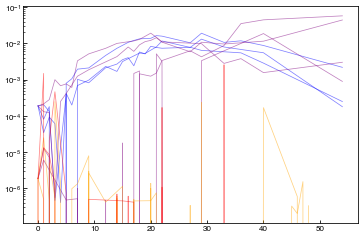

In [119]:
fig2_examples = {
'AGACGACAATATCCACTTTC': ([5, 4], 'lightblue', 0, 0, 'E'),
    'TCCGTTAACCTTCATAGTTG':([6, 7], 'gold', 0, 1, 'F'),
    'CGGTTGCGGTATTACAAGTC': ([5, 4], 'lightblue', 1, 0, 'G'),
    'ATTAACCGTTGACCGCTGCT': ([6, 7], 'gold', 1, 1, 'H'),
    'TGTAGTAGGCATAATAACCC': ([5, 4], 'lightblue', 2, 0, 'I'),
    'AACTACTCTTTGCATTTCCG': ([6, 7], 'gold', 2, 1, 'J')}


mouse_colors = {1:'blue', 2:'blue', 3:'blue', 4:'purple', 5:'purple', 6:'purple', 7:'purple', 8:'orange', 9:'orange', 10:'orange', 11:'red', 12:'red', 13:'red'}
for mut, barcodes in all_vivo_drivers.items():
    # tot_clones = np.sum([len(barcodes[barcode]['all']) for barcode in barcodes])
    tot_clones = np.sum([len(barcodes[barcode]['all']) for barcode in barcodes if len(barcode_clone_map[barcode]['all']) > 1])

    # if tot_clones > 1 and mut[-1] in ['False', '']:
    if tot_clones > 0 and mut[-1] not in ['True']: #exclude synonymous
        print(mut, tot_clones, len(barcodes), list(barcodes.keys()))

    
        # fig, ax = plt.subplots()
        for barcode in barcodes:
            if barcode != 'AGACTTTACCGACTACTGGC': continue
            fig, ax = plt.subplots()
            for mouse in range(1, 14):
                days, rows, cec = shared.mouse_meta['E1'][mouse]
                bc_idx = np.where(shared.barcodes == barcode)[0]
                freqs = shared.freq_array[rows][:, bc_idx]
                ax.plot(days, freqs, color=mouse_colors[mouse], alpha=0.5)
        ax.set_yscale('log')


        for barcode in barcodes:
            if barcode in fig2_examples:
                print('>> Fig 2 example', mut, fig2_examples[barcode])
            if barcode in [shared.LE1, shared.LE2]:
                print(f'>> LE{[shared.LE1, shared.LE2].index(barcode)+1}')
        print('\n')


    # if tot_clones > 1 and mut[-1] not in ['False', 'True', '']:
    #     print(mut, tot_clones, len(barcodes), list(barcodes.keys()))
    #     for barcode in barcodes:
    #         if barcode in fig2_examples:
    #             print('>> Fig 2 example', mut, fig2_examples[barcode])


In [11]:
## make list of putative driver mutations

f = open(f'{tables_dir}/tableS1_putative_driver_mutations.tsv', 'w')
header = f'barcode\tday\tn_isolates\tsampled mice\tsimple mutations\tstructural variant evidence\t(pos, locus, mut_type, n_isolates)\n'
f.write(header)
n_barcodes_with_candidate_drivers = 0
all_vivo_drivers = set()

barcode_mutations = {barcode[:20]:set() for barcode, clones in ordered_barcodes}
old_barcode = ''
for b, (barcode, tot_clones) in enumerate(ordered_barcodes):

    for day in ['all', 9, 17, 36, 51]: ## sampled at multiple timepoints
        if (len(barcode_clone_map[barcode]) <= 2 and day == 'all') or day not in barcode_clone_map[barcode]:
            continue
        barcode_clones = barcode_clone_map[barcode][day]

        sampled_mice = sorted(set([str(mouse) for (mouse, day, clone) in barcode_clones]), key=lambda x: int(x))
        n_clones = len(barcode_clones)

        mut_lst = []
        for mut, clones in all_mutations_in_isolates.items():
            if mut[1] in ['JC', 'MC']:
                continue
            count = 0
            for clone in clones.keys():
                if clone in barcode_clones: count += 1
            if not count > 0.5 * n_clones: continue # not present in at least half of clones (sampled at that timepoint)


            position, mut_type, gene, strand, gene_description, PUL, mutation, mutation_description, syn = mut    
            mutation_summary = f'{position}, {gene}, {mutation_description} (syn={syn})'
            mut_lst.append([count, mutation_summary])
            barcode_mutations[barcode[:20]].add(mut)


            all_vivo_drivers.add((mut, mut[1]))

        SV_lst = []
        tentative_list = []
        for SV, (SV_clones, SV_barcodes, pval, tested_bool, median_freq) in SV_processed.items():
            mut_type = SV[-1]
            if mut_type == 'unpaired_JC':
                locus1 = SV[0]
                gene1, gene2 = locus1[2][0], locus1[2][1]
                SV_info = f'{locus1[0][0]}/{locus1[0][1]}, {gene1}/{gene2}, {mut_type}'
                # clones, mut_type = merged_JCs[SV]
            else:

                JC1, JC2 = SV[0][0], SV[0][1]
                locus1, locus2 = JC1[0], JC2[0]
                gene1_loc1, gene2_loc1 = JC1[2][0], JC1[2][1]
                gene1_loc2, gene2_loc2 = JC2[2][0], JC2[2][1]
                if (gene1_loc1, gene2_loc1) == (gene1_loc2, gene2_loc2):
                    SV_info = f'{locus1[0]}-{locus2[1]}, {gene1_loc1}/{gene2_loc1}, {mut_type}'
                else:
                    SV_info = f'{locus1[0]}/{locus1[1]}-{locus2[0]}/{locus2[1]}, {gene1_loc1}/{gene2_loc1}-{gene1_loc2}/{gene2_loc2}, {mut_type}'

            count = 0 
            for clone in SV_clones:
                if clone in barcode_clones: count += 1
            if not count > 0.5 * n_clones: continue # not present in at least half of clones (sampled at that timepoint)


            if ~np.isnan(pval) and pval > FDR_alpha: # randomly distributed across barcodes
                continue
            if  median_freq < 0.5: # probably from in vitro colony growth
                continue

            all_vivo_drivers.add(SV)
            barcode_mutations[barcode[:20]].add(SV)
            SV_lst.append([count, SV_info])

        barcode_line = f'{barcode}\t{day}\t{n_clones}\t{",".join(sampled_mice)}\t'
        barcode_line += f'{len(mut_lst)}\t'
        barcode_line += f'{len(SV_lst)}\t'
        barcode_line += '\t'.join([f'{mutation}, n={count}' for (count, mutation) in mut_lst] + [f'{SV_info}, n={count}' for (count, SV_info) in SV_lst]) + '\n'
        f.write(barcode_line)
    f.write('\n')
f.close()


In [287]:
##
all_driver_loci = set()


with open(f'{tables_dir}/tableS2_putative_driver_mutations.tsv', 'r') as f:
    barcode_sv_dict = {}
    lines = f.readlines()
    header = lines[0]
    lines = lines[1:]
    
    for line in lines:
        if line == '\n':
            continue
        line_items = line.strip('\n').split('\t')

        barcode = line.split('\t')[0]
        if len(barcode_clone_map[barcode]['all']) > 1 and line_items[1] != 'all':
            continue

        # if line_items[1] != 'all':
        #     continue

        # print(line_items)
        muts = line_items[6:]

        barcode_sv_dict[barcode] = {'IR-inversion':[], 'other':[]}
        if muts[0] == '':
            continue
        for mut in muts:
            loci = mut.split(',')[1].strip(' ').split('-')
            for locus in loci:
                if np.any([e in mut for e in ['IR-inversion', 'insertion', 'unpaired', 'SV']]):
                    continue
                if '(syn=True)' in mut:
                    print('exclude')
                    continue
                for gene in locus.split('/'):

                    all_driver_loci.add(gene)
                        

            if 'IR-inversion' in mut:
                barcode_sv_dict[barcode]['IR-inversion'].append(mut)
            else:
                barcode_sv_dict[barcode]['other'].append(mut)

inversion_only = 0
for barcode in barcode_sv_dict.keys():
    if len(barcode_sv_dict[barcode]['IR-inversion']) > 0 and len(barcode_sv_dict[barcode]['other']) == 0:
        print(barcode, len(barcode_clone_map[barcode]['all']), barcode_sv_dict[barcode]['IR-inversion'], barcode_sv_dict[barcode]['other']) 
        inversion_only += 1
print(inversion_only)


exclude
exclude
exclude
ATTTTTGTCGTCGAATCATG 8 ['5939745-5943521, BT4520/BT4523, IR-inversion, n=5'] []
CAGCAGCAATCACAGGCGAT 3 ['5233175-5233352, BT4014-BT4015/BT4014-BT4015, IR-inversion, n=3', '5939745-5943521, BT4520/BT4523, IR-inversion, n=3', '5961660-5964004, BT4540/BT4543, IR-inversion, n=3'] []
GGACGTAATCCGATCACACA 3 ['5961660-5964004, BT4540/BT4543, IR-inversion, n=3'] []
GTACGCATCCCTCTCATATC 3 ['5939745-5943521, BT4520/BT4523, IR-inversion, n=2'] []
AATATACGGTTCCTTCCTGC 2 ['5961660-5964004, BT4540/BT4543, IR-inversion, n=2'] []
AATAAGATCCGACAATATAC 2 ['5939745-5943521, BT4520/BT4523, IR-inversion, n=2'] []
TATGTACTCCTCTTCGTGTT 2 ['5939745-5943521, BT4520/BT4523, IR-inversion, n=2'] []
CGGTCACGGTTAGTAATTCG 1 ['5939745-5943521, BT4520/BT4523, IR-inversion, n=1'] []
TGCTCCCAGTCCTGATAGAT 1 ['5961660-5964004, BT4540/BT4543, IR-inversion, n=1'] []
TGGCGATCTACCCGATTGCA 1 ['3316290/3316499-3316302/3316485, BT2660-BT2661/BT2661-BT2660-BT2661/BT2660-BT2661, IR-inversion, n=1'] []
GGGTT

In [23]:
GO_str = ''
for locus in all_driver_loci:
    # GO_str += ' BT_'+locus.strip('BT')
    try:
        print('BT_'+locus.strip('BT'), breseq.gene_PUL_map[locus][0], shared.gene_description[locus])
    except:
    
        print('BT_'+locus.strip('BT'),)



# GO_str = GO_str.lstrip(', ')
# print(GO_str)

NameError: name 'all_driver_loci' is not defined

In [22]:
simple_only, SV_only, both, none = 0, 0, 0, 0
for barcode, muts in barcode_mutations.items():
    simple_count, sv_count = 0, 0
    for mut in muts:
        if np.any([e == mut[-1] for e in ['SV', 'unpaired_JC', 'IR-inversion', 'insertion']]):
            sv_count += 1
        else:
            simple_count += 1
    if simple_count > 0 and sv_count > 0:
        both += 1
    elif simple_count > 0:
        simple_only += 1
    elif sv_count > 0:
        SV_only += 1
    else:
        none += 1
print(f'{both} barcodes with simple mutations + SVs in majority of isolates')
print(f'{simple_only} barcodes with simple mutations only in majority of isolates')
print(f'{SV_only} barcodes with SVs only in majority of isolates')
print(f'{none} barcodes with no mutations in majority of isolates')


TypeError: 'int' object is not subscriptable